In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.decomposition import PCA 
from sklearn.datasets import load_digits

In [2]:
dataset = load_digits()

In [3]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [4]:
X = df
y = dataset.target 

In [5]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=30)

In [7]:
km = KMeans(n_clusters=10)
y_pred = km.fit_predict(X_train)
km.inertia_

57443.90042528987

In [8]:
from sklearn.metrics import silhouette_score

print("Silhouette:", silhouette_score(X_train, y_pred))
print("Inertia (SSE):", km.inertia_)

Silhouette: 0.11650524396414157
Inertia (SSE): 57443.90042528987


In [9]:
pca = PCA(0.95)
X_pca = pca.fit_transform(X)
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=30)

In [10]:
km = KMeans(n_clusters=10)
y_pred = km.fit_predict(X_train_pca)
km.inertia_

901811.5159682531

In [11]:
from sklearn.metrics import silhouette_score

print("Silhouette:", silhouette_score(X_train_pca, y_pred))
print("Inertia (SSE):", km.inertia_)

Silhouette: 0.14934601023598768
Inertia (SSE): 901811.5159682531


Termination criterion satisfied, k means has converged


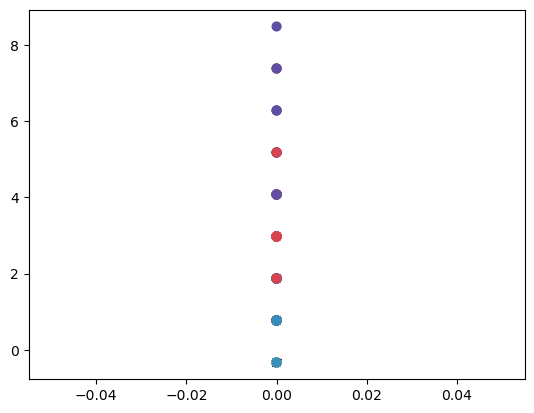

In [13]:
class KMeansClustering():
    def __init__(self, X , num_clusters):
        self.K = num_clusters
        self.plot_figure = True
        self.max_iterations = 100
        self.num_examples, self.num_features = X.shape

    def initialize_random_centroids(self, X):
        centroids = np.zeros((self.K, self.num_features)) # initialize random centroids

        for k in range(self.K):
            centroid = X[np.random.choice(range(self.num_examples))]    #Her bir küme için X’ten rastgele bir nokta seçiliyor ve o kümenin başlangıç merkezi yapılıyor.
            centroids[k] = centroid

        return centroids

    def create_clusters(self, X, centroids):
        clusters = [[] for _ in range(self.K)]

        for point_idx, point in enumerate(X):
            closest_cetroid = np.argmin(np.sqrt(np.sum((point - centroids)**2, axis=1)))   # point tek bir satır(feature vektör) centroids bir array -> broadcasting
            clusters[closest_cetroid].append(point_idx)

        return clusters     # clusters = [[0,3,5], [1,4], [2]] Xte hangi satır(example) olduğunu saklıyor

    def calculate_new_centroids(self, clusters, X):
        centroids = np.zeros((self.K, self.num_features))

        for idx, cluster in enumerate(clusters):
            new_centroid = np.mean(X[cluster], axis=0) # cluster= en yakın noktaların indexi yani hangi satırda olduğu. Xten o satırların ortalaması alınır
            centroids[idx] = new_centroid

        return centroids

    def predict_cluster(self, clusters, X):
        y_pred = np.zeros(self.num_examples)

        for cluster_idx, cluster in enumerate(clusters):
            for sample_idx in cluster:
                y_pred[sample_idx] = cluster_idx

        return y_pred

    def plot_fig(self, X, y):
        plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap=plt.cm.Spectral)
        plt.show()

    def fit(self, X):
        centroids = self.initialize_random_centroids(X)

        for it in range(self.max_iterations):
            clusters = self.create_clusters(X, centroids)

            previous_centroids = centroids
            centroids = self.calculate_new_centroids(clusters, X)

            diff = centroids - previous_centroids

            if not diff.any():
                print("Termination criterion satisfied, k means has converged")
                break

        y_pred = self.predict_cluster(clusters, X)

        if self.plot_figure:
            self.plot_fig(X, y_pred)

        return y_pred

np.random.seed(10)
num_clusters  = 10
    
Kmeans = KMeansClustering(X_train, num_clusters)
y_pred = Kmeans.fit(X_train)

In [15]:
print("Silhouette:", silhouette_score(X_train, y_pred))
print("Inertia (SSE):", km.inertia_)

Silhouette: 0.13847215590398174
Inertia (SSE): 901811.5159682531
